<a href="https://colab.research.google.com/github/data4class/Teaching/blob/main/kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Intitialize k points and number them 1 to k (centroids).
2. For each points in P compute the distances from k centroids.
3. Compute the minimum of these distances for each point.
4. Assign the cluster to each point (n points) based on minimum distance from centroids.
5. Update the centroids of clusters.
6. Repeat steps 2-5 if centroids changes.

Short notes on kmeans found here:
https://www.niser.ac.in/~smishra/teach/cs460/2020/lectures/lec22/

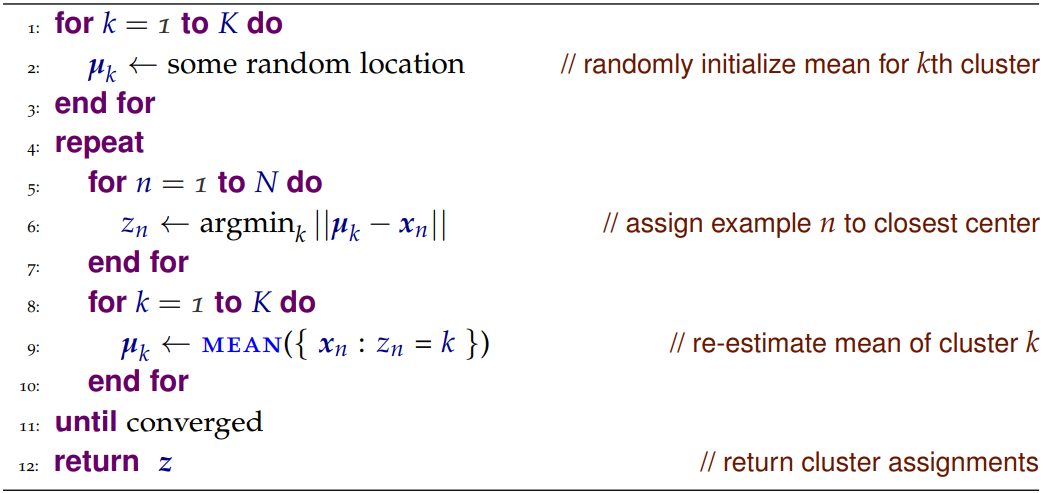

In [ ]:
## while termination: (i)
##    for each point p in N:  (N)
##           for each centroid c in Ctr: (K)
##               distance between c and p  (2d)
## i*N*K*2d = O(NKdi) - linear in N, K, d

import random
# def kmeans(P,k):
#1.  P is collections of point i.e. tuple => P is list of tuples.
#2.  select k random points and label them 1 to k. (use random)
#3.  for each point pt in P, compute distances (k difference distance) of pt from labeled points.
#4.  label(pt)  = label (argmin (distance))
#5.  for each label ell, compute the centroid of points with label ell.
#6.  check termination else GoTo 3.

#HW: read DBSCAN ( Another algorithm ) and implement it.

def kmeans(P,k):
    n=len(P) # Number of rows of input P
    d=len(P[0]) # Number of columns of input P
    # centroids and centroids_old are two different copy of centroids.
    # In centroids_old, we will keep the centroids from the previous iteration:  see the while loop
    clusters = []  # (pt -> label) 1 ->2, 2 ->2, 3 -> 1, 4 -> 2 clusters = [2,2,1,2]
    centroids = []
    centroids_old = []
    # Initialize random centroids from the data points
    initial = random.sample(range(n), k)# positions or index
    for i in initial:
        centroids.append(P[i])
        centroids_old.append(0)
    # While loop is running until centroids gets stable (does not changes)
    while(centroids != centroids_old):   # You can chnage this termination condition to a better one: Exercise1
        centroids_old = centroids.copy() # Copy the current centroids in old one so that we can update the current centroids
        centroids = []                   # Empty the current centroids
        clusters = []                    # Initialize the clusters to nil.
        countc = {i: 0 for i in range(k)} # Initialize dictionary to count number of points in each cluster
        for i,x in enumerate(P):    # This loop over each point x in our input
            cdistances = []         # Initialize distance of curent point with all centroids
            for c in centroids_old: # loop over each centroid c
                # computing distance square
                dist = 0
                for j in range(d):
                    dist += (c[j] - x[j])**2
                ## Why we are not computing sqrt of dist? Is it needed? Extra computation that is not needed in this context.
                # append the distance of current point x with current centroid c
                cdistances.append(dist)
            ## Here you have all the distances of point x with all the centroids
            cidx = cdistances.index(min(cdistances)) # Fining which centroid is closest to the x.
            countc[cidx] += 1                      # Increment the number of points in cluster cidx
            clusters.append(cidx)             # append cluster id cidx for point x
        # Initialize dictionary sum_cord_centroids to compute total sums for each coordinate of points in each clusters.
        # This is helpful to update centroids later quickly
        sum_cord_centroids = {j: {i: 0 for i in range(d)} for j in range(k)}
        ## Can you make below loop faster or smaller steps?
        for i,c in enumerate(clusters):
            for s in range(k):
                if(c == s):
                    for j in range(d):
                        sum_cord_centroids[s][j] += P[i][j]
        # Updating centroids ## Can you make below loop faster or smaller steps as well?
        for s in sum_cord_centroids:
            for j in range(d):
                sum_cord_centroids[s][j] = sum_cord_centroids[s][j]/countc[s]
            centroids.append(tuple(sum_cord_centroids[s].values()))

    # Calculate inertia
    inertia = 0
    for i, x in enumerate(P):
        c = centroids[clusters[i]]
        dist = 0
        for j in range(d):
            dist += (c[j] - x[j])**2
        inertia += dist

    return(clusters, centroids, inertia)
  # where clusters is a list specifying which cluster each point belogs to
  #for example, clusters = [1, 2, 1, 0, 0] means first and third points belongs to cluster number 1, second point belongs to
  #cluster number 2, and forth and fifth point belongs to cluster number 0.

## Exercise: Generalize above code to output sum of distance sqaure between each point and its centroid.
## Done
P = [(2, 3),(1, 0),(-3, 6),(0, -3),(-1,7)]
cc, centroids, inertia = kmeans(P, 2)
print(cc)
print(centroids)
print(inertia)

[0, 0, 1, 0, 1]
[(1.0, 0.0), (-2.0, 6.5)]
22.5


In [ ]:
#Demo (for the above code)
import random
import matplotlib.pyplot as plt
def points3cluster(n):
    m1 = random.randint(round(n/4), round(2*n/5))
    m2 = random.randint(round(n/3), round(3*n/5))
    m3 = n - m1 - m2
    lx1 = [random.uniform(-3,3) for i in range(m1)]
    ly1 = [random.uniform(1,5) for i in range(m1)]
    lx2 = [random.uniform(-5.5,-.5) for i in range(m2)]
    ly2 = [random.uniform(-5,-1) for i in range(m2)]
    lx3 = [random.uniform(1,6) for i in range(m3)]
    ly3 = [random.uniform(-5.7,-1.1) for i in range(m3)]
    P = list(zip(lx1 + lx2 + lx3, ly1 + ly2 + ly3))
    random.shuffle(P)
    return(P)

n = 100
P = points3cluster(n)


Time taken 0.0018718242645263672 seconds


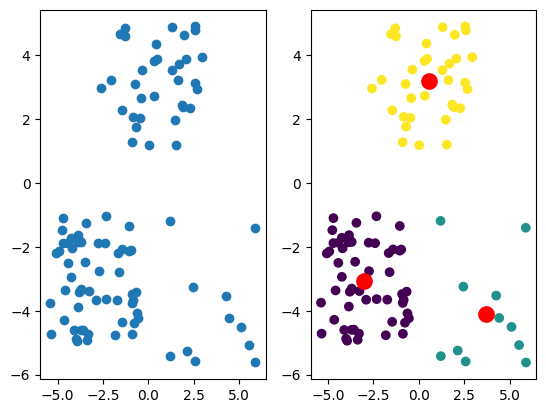

In [ ]:
import numpy as np
from sklearn.cluster import k_means
import time
start_time1 = time.time()
n = 100
P = points3cluster(n)
clusters, centroids, inertia = kmeans(P, 3)

#print(centroids)
#print(clusters)
#print(inertia)
#clusters, centroids = kmeans(P,3)
start_time2 = time.time()

print("Time taken %s seconds" %(start_time2 - start_time1))

plt.subplot(1, 2, 1)
plt.scatter(*zip(*P))

plt.subplot(1, 2, 2)
#colours = zip(*clusters)
plt.scatter(*zip(*P),c=clusters)
plt.scatter(*zip(*centroids),c='r',linewidths=6)
plt.show()